In [1]:
# Importing essential libraries
import numpy as np
import pandas as pd

In [2]:
# Loading the dataset
messages = pd.read_csv('review.tsv', sep='\t',quoting=3)

In [3]:
messages.shape

(16244, 3)

In [4]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16244 entries, 0 to 16243
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Name     16244 non-null  object 
 1   content  15938 non-null  object 
 2   score    15554 non-null  float64
dtypes: float64(1), object(2)
memory usage: 380.8+ KB


In [5]:
messages.columns

Index(['Name', 'content', 'score'], dtype='object')

In [6]:
messages.head()

,Name,content,score
0,Andrew Thomas,Update: After getting a response from the deve...,1.0
1,Craig Haines,Used it for a fair amount of time without any ...,1.0
2,steven adkins,Your app sucks now!!!!! Used to be good but no...,1.0
3,Lars PanzerbjÃ¸rn,"It seems OK, but very basic. Recurring tasks n...",1.0
4,Scott Prewitt,Absolutely worthless. This app runs a prohibit...,1.0


# Data Cleaning & Preprocessing

In [7]:
messages.score.unique()

array([ 1.,  2.,  3.,  4.,  5., nan])

In [35]:
def to_sentiment(rating):
  rating = rating
  if rating <= 2:
    return 'negative'
  elif rating == 3:
    return 'neutral'
  else: 
    return 'positive'

messages['sentiment'] = messages.score.apply(to_sentiment)

In [36]:
import re
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer #to find the root word

In [38]:
ps = PorterStemmer()
corpus = []

In [39]:
for i in range (0,len(messages)):
    # Cleaning special character from the reviews
    review = re.sub('[^a-zA-Z]',' ',str(messages['content'][i]))
    
    # Converting the entire review into lower case
    review = review.lower()
    
    # Tokenizing the review by words
    review_words = review.split()
    
    # Stemming the words and removing the stopwords
    review = [ps.stem(word) for word in review_words if not word in set(stopwords.words('english')) ]
    
    # Joining the stemmed words
    review = ' '.join(review)

    # Creating a corpus
    corpus.append(review)

In [40]:
corpus[0:10]

['updat get respons develop would chang rate star possibl guy hide behind confus opaqu term refus budg annoy money lost realli terribl custom experi origin care sign free trial app happen go automat charg full year subscript refus refund terribl custom experi app ok',
 'use fair amount time without problem suddenli ask creat account log use googl fb use googl one discov everyth gone',
 'app suck use good updat physic open close scroll final show want put list friggen paid garbag',
 'seem ok basic recur task need work actual use exampl would nice abl set task recur first everi month without abl set first month edit also notic dark theme may avail paid option never know sinc basic option without reason tri app thu never pay actual premium option',
 'absolut worthless app run prohibit clunki interfac effect void promis eas life autom googl calendar provid servic promis free annual subscript rate sign free trial worth get ping forti buck decid like forget cancel time save money',
 'bewar t

In [41]:
# Creating the Bag of Words model
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(corpus).toarray()
y = messages['sentiment'].values

In [45]:
X.shape

(16244, 1500)

In [46]:
y.shape

(16244,)

# Training Model

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [48]:
# Fitting Naive Bayes to the Training set
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()
classifier.fit(X_train, y_train)

MultinomialNB()

In [49]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)

In [55]:
# Accuracy, Precision and Recall
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
score1 = accuracy_score(y_test,y_pred)
print("---- Scores ----")
print("Accuracy score is: {}%".format(round(score1*100,2)))

---- Scores ----
Accuracy score is: 63.1%


In [56]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[677, 230, 126],
       [276, 407, 288],
       [108, 171, 966]], dtype=int64)

Text(69.0, 0.5, 'Actual values')

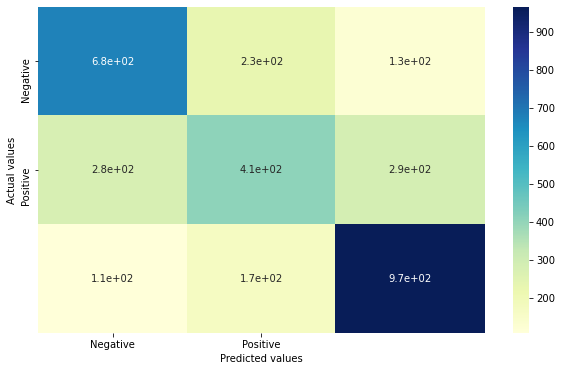

In [57]:
# Plotting the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.figure(figsize = (10,6))
sns.heatmap(cm, annot=True, cmap="YlGnBu", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted values')
plt.ylabel('Actual values')

In [58]:
# Hyperparameter tuning the Naive Bayes Classifier
best_accuracy = 0.0
alpha_val = 0.0
for i in np.arange(0.1,1.1,0.1):
  temp_classifier = MultinomialNB(alpha=i)
  temp_classifier.fit(X_train, y_train)
  temp_y_pred = temp_classifier.predict(X_test)
  score = accuracy_score(y_test, temp_y_pred)
  print("Accuracy score for alpha={} is: {}%".format(round(i,1), round(score*100,2)))
  if score>best_accuracy:
    best_accuracy = score
    alpha_val = i
print('--------------------------------------------')
print('The best accuracy is {}% with alpha value as {}'.format(round(best_accuracy*100, 2), round(alpha_val,1)))

Accuracy score for alpha=0.1 is: 63.47%
Accuracy score for alpha=0.2 is: 63.5%
Accuracy score for alpha=0.3 is: 63.43%
Accuracy score for alpha=0.4 is: 63.47%
Accuracy score for alpha=0.5 is: 63.43%
Accuracy score for alpha=0.6 is: 63.22%
Accuracy score for alpha=0.7 is: 63.25%
Accuracy score for alpha=0.8 is: 63.31%
Accuracy score for alpha=0.9 is: 63.13%
Accuracy score for alpha=1.0 is: 63.1%
--------------------------------------------
The best accuracy is 63.5% with alpha value as 0.2


In [59]:
classifier = MultinomialNB(alpha=0.2)
classifier.fit(X_train, y_train)

MultinomialNB(alpha=0.2)

# Predictions

In [60]:
def predict_sentiment(sample_review):
  sample_review = re.sub(pattern='[^a-zA-Z]',repl=' ', string = sample_review)
  sample_review = sample_review.lower()
  sample_review_words = sample_review.split()
  sample_review_words = [word for word in sample_review_words if not word in set(stopwords.words('english'))]
  ps = PorterStemmer()
  final_review = [ps.stem(word) for word in sample_review_words]
  final_review = ' '.join(final_review)
  print(final_review)

  temp = cv.transform([final_review]).toarray()
  print(classifier.predict(temp))
  return classifier.predict(temp)

In [63]:
# Predicting values
sample_review = 'The food is really worst here.'
predict_sentiment(sample_review)

food realli worst
['negative']


array(['negative'], dtype='<U8')

In [64]:
# Predicting values
sample_review = 'The food is really great here.'
predict_sentiment(sample_review)

food realli great
['positive']


array(['positive'], dtype='<U8')